## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# METEOR Interface (new simplified API)
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


## 2. Initialize and Train Emulator

The `MeteorInterface` handles all the complexity:
- Data loading from CMIP6
- Pattern scaling model training
- Noise model training
- Variable-specific transforms (precipitation → Gamma distribution)

In [2]:
# Create emulator for both temperature and precipitation
emulator = MeteorInterface(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"TAS transform: {emulator.transforms['tas'].transform_type}")
print(f"PR transform: {emulator.transforms['pr'].transform_type} ")

Emulator created for: ['tas', 'pr']
TAS transform: None
PR transform: gamma 


In [3]:
# Define regions and points
regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    #'Santiago': {'lat': -33.4, 'lon': 289.3},  # -70.7°W = 289.3°E
    'Cairo': {'lat': 30.0, 'lon': 31.2},
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

print(f"Regions: {', '.join(regions)}")
print(f"Cities: {', '.join(cities.keys())}")

Regions: NEU, NSA, EAS
Cities: Oslo, Delhi, Cairo, Beijing


In [4]:
# Train models (uses cached models if available)
emulator.train(auto=True, verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Cache file not found: ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
🔧 Preparing pattern scaling training data for NorESM2-MM...
   Limiting piControl data to first 150 years (was 500 years)
   Limiting piControl data to first 150 years (was 500 years)
   ✅ Training data prepared for experiments: ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
✅ Pattern scaling model saved to ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
💾 Cached pattern scaling model to ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
      ⚠️  Training new noise model...
      → Using ssp245 pattern prediction for training
      → 

## 3. Define Locations

**Regions (AR6):**
- NEU: Northern Europe
- GIC: Greenland/Iceland
- NSA: Northern South America
- EAS: East Asia

**Cities:**
- Oslo: 59.9°N, 10.8°E
- Delhi: 28.6°N, 77.2°E
- Santiago: -33.4°S, -70.7°W (289.3°E)
- Beijing: 39.9°N, 116.4°E

## 4. Generate Ensemble

Generate 100 realizations with:
- Global mean
- 4 regional means
- 4 point locations
- Heating degree days for temperature

In [5]:
# Build aggregation list
timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Generating {len(timeseries)} spatial aggregations:")
for ts in timeseries:
    print(f"  - {ts}")

Generating 8 spatial aggregations:
  - global
  - regional:NEU
  - regional:NSA
  - regional:EAS
  - point:59.9,10.8
  - point:28.6,77.2
  - point:30.0,31.2
  - point:39.9,116.4


In [6]:
# Reload the meteor_interface module to pick up recent changes
import importlib
import meteor.meteor_interface
importlib.reload(meteor.meteor_interface)
from meteor import MeteorInterface
print("✅ Module reloaded")

✅ Module reloaded


In [7]:
ensemble245 = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=10,
    timeseries=['global', 'regional:NEU'],
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 10

📊 Generating TAS...
   → Time series: 2 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
      • regional:NEU
   → Computing impact metrics...
         • HDD for global
         • CDD for global
         • HDD for regional:NEU
         • CDD for regional:NEU
   ✅ TAS complete

📊 Generating PR...
   → Time series: 2 aggregations
      → Computing pattern scaling for pr, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for pr...
      → Using 1850 baseline for PR instead of piControl
      → Generating 10 stochastic PC realizations...
      • global
      • regional:NEU
   ✅ PR complete

✅ Generation complete


In [8]:
ensemble245['tas'].impacts

{'hdd': {'global': array([[1491.53448428, 1559.12155874, 1533.5805549 , ...,  738.32209323,
           708.52972277,  737.12592427],
         [1510.33918283, 1498.67506533, 1496.77648873, ...,  694.33784357,
           732.0708309 ,  738.0622963 ],
         [1493.35719794, 1545.60348319, 1532.33830788, ...,  760.29623807,
           730.32908443,  739.27408812],
         ...,
         [1514.17508286, 1542.46994585, 1549.78962511, ...,  720.74902871,
           717.99327572,  690.55108221],
         [1493.93949713, 1525.52453577, 1538.8083864 , ...,  766.77415968,
           732.94007471,  749.90793384],
         [1518.03029389, 1494.22804081, 1525.03343369, ...,  713.31792194,
           718.8705693 ,  712.78952485]], shape=(10, 251)),
  'regional:NEU': array([[4874.27495752, 5237.21993268, 5035.4039764 , ..., 4445.24805487,
          4182.01106512, 4526.29830602],
         [5126.34844456, 4979.57201313, 4999.18664772, ..., 4404.47412566,
          4315.04218631, 4458.7034785 ],
      

In [9]:
# Generate ensemble with custom EU NECP emissions
# Note: This scenario runs 1750-2050, so we'll generate to 2050
ensemble_custom = emulator.generate_ensemble_outputs(
    scenario={
        'emissions': 'notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=1850,
    end_year=2050,  # Match emissions data availability
    n_realizations=50,  # Fewer realizations for demo
    timeseries=['global', 'regional:NEU'],
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

print(f"\n✅ Custom scenario ensemble generated!")
print(f"Scenario: {ensemble_custom.metadata['scenario']}")
print(f"Variables: {ensemble_custom.metadata['variables']}")

Generating ensemble for EU_NECP_2024
  Years: 1850-2050
  Realizations: 50

📊 Generating TAS...
   → Time series: 2 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 50 stochastic PC realizations...
      • global
      • regional:NEU
   → Computing impact metrics...
         • HDD for global
         • CDD for global
         • HDD for regional:NEU
         • CDD for regional:NEU
   ✅ TAS complete

📊 Generating PR...
   → Time series: 2 aggregations
      → Computing pattern scaling for pr, custom scenario 'EU_NECP_2024'...
      → Loade

In [10]:
ensemble_custom['tas'].impacts

{'hdd': {'global': array([[1499.66218805, 1556.94251676, 1514.00198953, ..., 1180.12187801,
          1208.19531466, 1170.53766096],
         [1536.61175663, 1511.32335126, 1487.22573582, ..., 1152.2092683 ,
          1182.04825342, 1164.26854933],
         [1524.94641246, 1514.81550918, 1484.20299205, ..., 1184.363178  ,
          1187.6953215 , 1168.57247672],
         ...,
         [1514.28834545, 1516.43341448, 1492.53925958, ..., 1195.19541272,
          1178.91000405, 1179.33243726],
         [1525.77389636, 1536.10068465, 1506.11060563, ..., 1214.3699634 ,
          1174.50397674, 1172.97447172],
         [1502.23089741, 1497.52666258, 1542.85525288, ..., 1197.95043859,
          1189.63897619, 1158.03789022]], shape=(50, 201)),
  'regional:NEU': array([[4935.28187442, 5283.363998  , 5309.76144765, ..., 5082.34500188,
          5028.33201518, 5209.39165857],
         [5254.14140133, 5174.72036727, 5110.48113835, ..., 4563.94346584,
          4843.82665732, 4766.43709687],
      

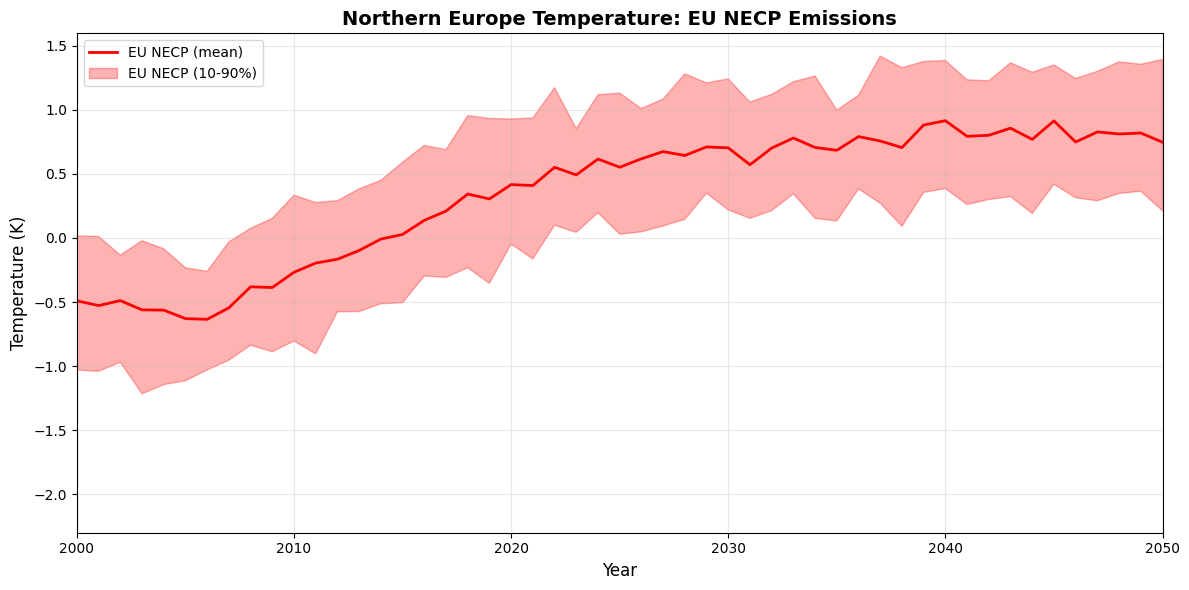

In [11]:
# Compare SSP245 vs EU NECP for Northern Europe temperature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Extract NEU regional data
custom_neu = ensemble_custom['tas'].timeseries['regional:NEU']

# Resample to annual for cleaner plot
def resample_annual(data):
    """Resample monthly to annual means"""
    n_years = len(data) // 12
    return data[:n_years*12].reshape(n_years, 12).mean(axis=1)


# EU NECP (1850-2050)
custom_annual = np.array([resample_annual(real) for real in custom_neu])
years_custom_annual = np.arange(1850, 1850 + len(custom_annual[0]))

ax.plot(years_custom_annual, custom_annual.mean(axis=0), 'r-', linewidth=2, label='EU NECP (mean)')
ax.fill_between(years_custom_annual,
                 np.percentile(custom_annual, 10, axis=0),
                 np.percentile(custom_annual, 90, axis=0),
                 alpha=0.3, color='red', label='EU NECP (10-90%)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Northern Europe Temperature: EU NECP Emissions', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 2050)

plt.tight_layout()
plt.show()


## 5. Define GCAM Regions

Define custom regions matching the 32 GCAM regions with approximate lat/lon bounding boxes.

In [12]:
# Define GCAM custom regions with approximate lat/lon bounding boxes
gcam_regions_org = {
    'USA': {'lat': (25, 50), 'lon': (-125, -65)},
    'Africa_Eastern': {'lat': (-12, 15), 'lon': (30, 50)},
    'Africa_Northern': {'lat': (15, 37), 'lon': (-17, 50)},
    'Africa_Southern': {'lat': (-35, -12), 'lon': (15, 35)},
    'Africa_Western': {'lat': (4, 15), 'lon': (-17, 16)},
    'Australia_NZ': {'lat': (-47, -10), 'lon': (110, 180)},
    'Brazil': {'lat': (-33, 5), 'lon': (-74, -34)},
    'Canada': {'lat': (41, 83), 'lon': (-141, -52)},
    'Central_America_Caribbean': {'lat': (7, 33), 'lon': (-118, -60)},
    'Central_Asia': {'lat': (35, 55), 'lon': (46, 87)},
    'China': {'lat': (18, 53), 'lon': (73, 135)},
    'EU_12': {'lat': (42, 58), 'lon': (-10, 30)},  # Eastern European EU members
    'EU_15': {'lat': (36, 60), 'lon': (-10, 15)},  # Western European EU members
    'Europe_Eastern': {'lat': (44, 52), 'lon': (20, 40)},  # Non-EU Eastern Europe
    'Europe_Non_EU': {'lat': (42, 47), 'lon': (13, 23)},  # Balkans
    'European_Free_Trade': {'lat': (46, 71), 'lon': (5, 31)},  # Norway, Switzerland, Iceland
    'India': {'lat': (8, 35), 'lon': (68, 97)},
    'Indonesia': {'lat': (-11, 6), 'lon': (95, 141)},
    'Japan': {'lat': (24, 46), 'lon': (123, 146)},
    'Mexico': {'lat': (14, 33), 'lon': (-117, -86)},
    'Middle_East': {'lat': (12, 42), 'lon': (34, 63)},
    'Pakistan': {'lat': (23, 37), 'lon': (60, 77)},
    'Russia': {'lat': (41, 82), 'lon': (19, 180)},
    'South_Africa': {'lat': (-35, -22), 'lon': (16, 33)},
    'South_America_Northern': {'lat': (-5, 12), 'lon': (-81, -50)},  # Colombia, Venezuela, Guyana region
    'South_America_Southern': {'lat': (-56, -27), 'lon': (-75, -53)},  # Chile, Argentina south
    'South_Asia': {'lat': (5, 30), 'lon': (79, 93)},  # Bangladesh, Sri Lanka region
    'South_Korea': {'lat': (33, 43), 'lon': (124, 132)},
    'Southeast_Asia': {'lat': (0, 28), 'lon': (92, 108)},  # Thailand, Vietnam, Myanmar
    'Taiwan': {'lat': (21, 26), 'lon': (119, 122)},
    'Argentina': {'lat': (-55, -21), 'lon': (-73, -53)},
    'Colombia': {'lat': (-4, 13), 'lon': (-79, -66)}
}

def convert_region_to_360(region_def):
    """Convert region definition from -180/180 to 0-360 longitude"""
    lat = region_def['lat']
    lon_min, lon_max = region_def['lon']
    
    # Convert negative longitudes to 0-360 format
    if lon_min < 0:
        lon_min = lon_min + 360
    if lon_max < 0:
        lon_max = lon_max + 360
    
    return {'lat': lat, 'lon': (lon_min, lon_max)}

# Create converted version of GCAM regions
gcam_regions = {
    name: convert_region_to_360(region_def) 
    for name, region_def in gcam_regions_org.items()
}


## 6. Test Custom Regions with GCAM

In [13]:
# Reload modules to pick up custom regions fix
import importlib
import meteor.pattern_logic_lib
import meteor.meteor_interface
importlib.reload(meteor.pattern_logic_lib)
importlib.reload(meteor.meteor_interface)
from meteor import MeteorInterface, create_region_mask
print("✅ Modules reloaded with custom regions support")

✅ Modules reloaded with custom regions support


In [14]:
# Build timeseries list for all GCAM regions
timeseries = ['global']
timeseries += [f'regional:custom:{region}' for region in gcam_regions.keys()]

print(f"Generating timeseries for {len(timeseries)} locations:")
print(f"  - global")
print(f"  - {len(gcam_regions)} GCAM regions")

# Generate ensemble
ensemble = emulator.generate_ensemble_outputs(
    scenario={
        'emissions': 'notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=2020,
    end_year=2050,
    n_realizations=10,
    timeseries=timeseries,
    custom_regions=gcam_regions,
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

print(f"\n✅ Ensemble generated for all GCAM regions!")

Generating timeseries for 33 locations:
  - global
  - 32 GCAM regions
Generating ensemble for EU_NECP_2024
  Years: 2020-2050
  Realizations: 10

📊 Generating TAS...
   → Time series: 33 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
      • regional:custom:USA
      • regional:custom:Africa_Eastern
      • regional:custom:Africa_Northern
      • regional:custom:Africa_Southern
      • regional:custom:Africa_Western
      • regional:custom:Australia_NZ
      • regional:custom:Brazil
    

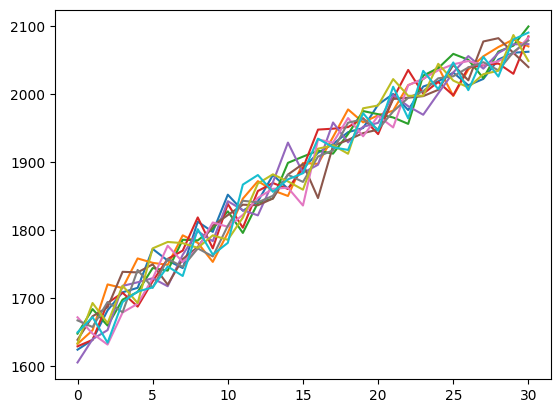

In [15]:
plt.plot(ensemble['tas'].impacts['cdd']['regional:custom:Africa_Northern'].T)

In [16]:
# Helper function to resample monthly to annual
def resample_annual(data):
    """Resample monthly to annual means"""
    n_years = len(data) // 12
    return data[:n_years*12].reshape(n_years, 12).mean(axis=1)

# Prepare data
start_year = 1990
region_names = list(gcam_regions.keys())
n_regions = len(region_names)

# Create years array for plotting
n_months = len(ensemble['tas'].timeseries['global'][0])
n_years = n_months // 12
years = np.arange(start_year, start_year + n_years)

print(f"Preparing data for {n_regions} regions from {start_year} to {start_year + n_years - 1}")
print(f"Shape: {n_months} months = {n_years} years")

Preparing data for 32 regions from 1990 to 2020
Shape: 372 months = 31 years


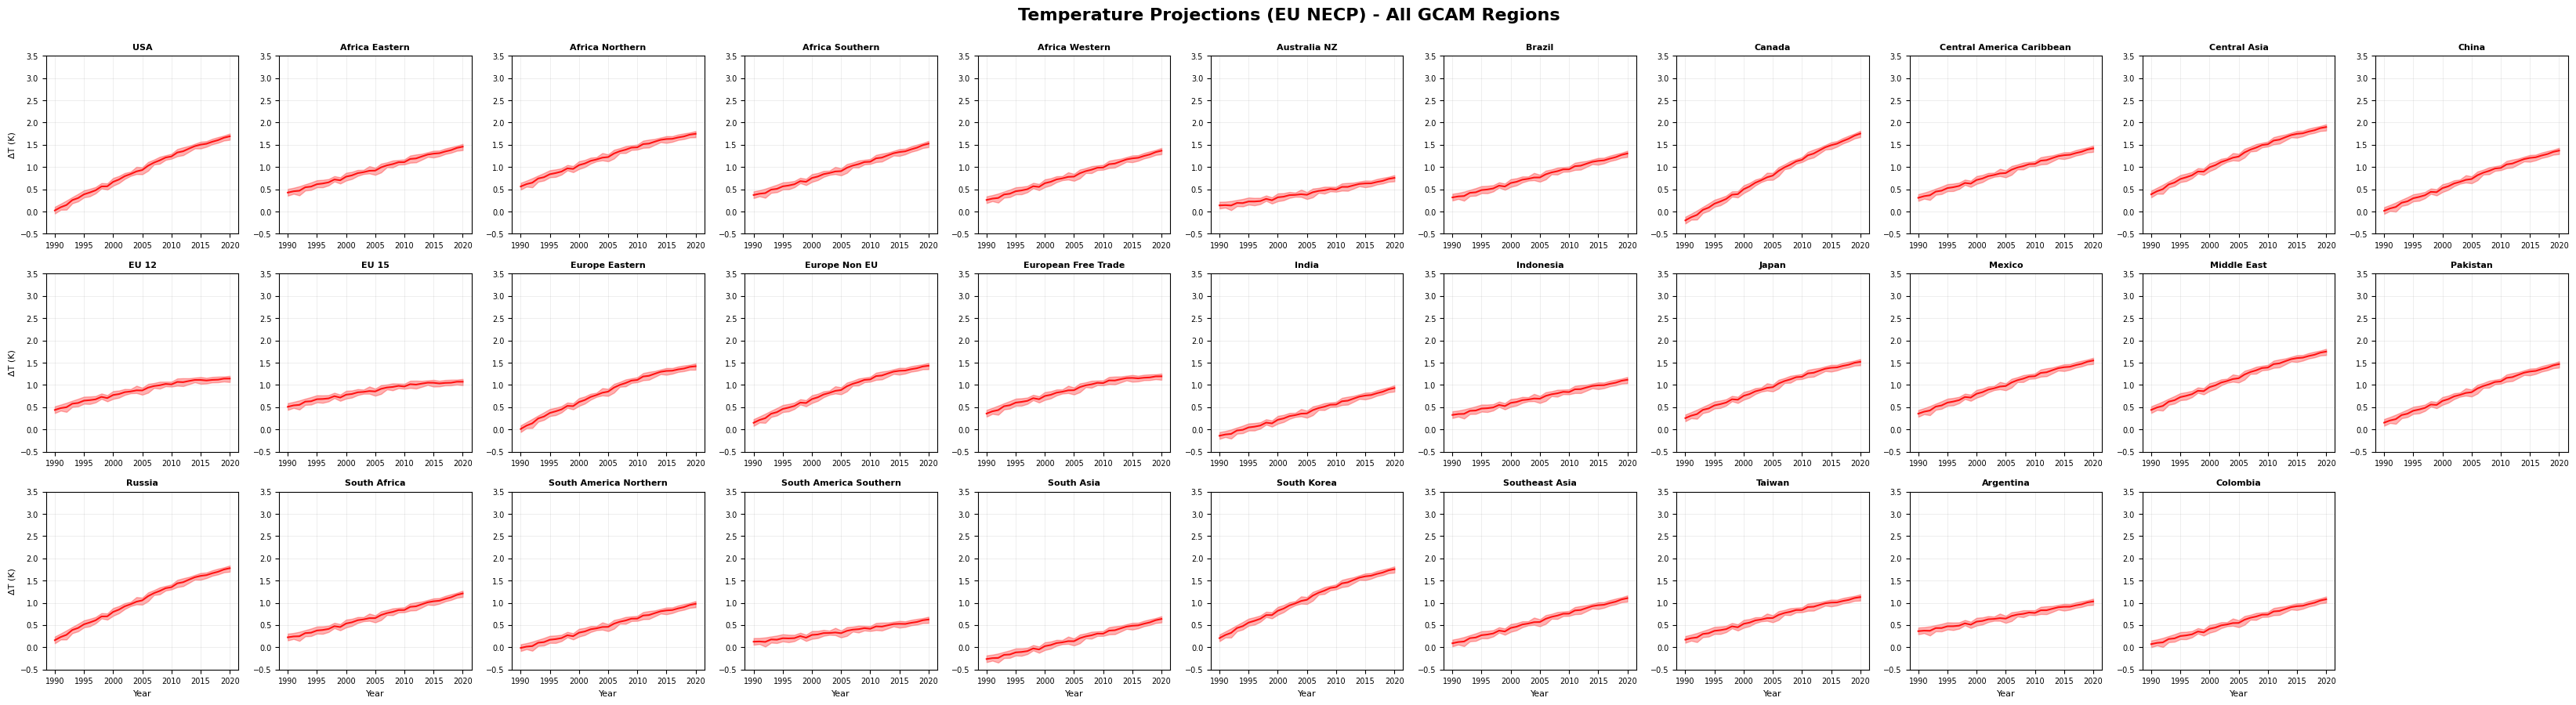

In [17]:
# Plot Temperature for all GCAM regions (3x11 grid)
fig, axes = plt.subplots(3, 11, figsize=(33, 9))
fig.suptitle('Temperature Projections (EU NECP) - All GCAM Regions', 
             fontsize=16, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, region_name in enumerate(region_names):
    ax = axes_flat[idx]
    
    # Get temperature data for this region
    key = f'regional:custom:{region_name}'
    tas_data = ensemble['tas'].timeseries[key]
    
    # Convert to annual means
    tas_annual = np.array([resample_annual(real) for real in tas_data])
    
    # Calculate statistics
    mean = tas_annual.mean(axis=0)
    p5 = np.percentile(tas_annual, 5, axis=0)
    p95 = np.percentile(tas_annual, 95, axis=0)
    
    # Plot
    ax.plot(years, mean, 'r-', linewidth=1.5, alpha=0.9)
    ax.fill_between(years, p5, p95, alpha=0.3, color='red')
    
    # Formatting
    ax.set_title(region_name.replace('_', ' '), fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=7)
    
    # Only show y-label on leftmost plots
    if idx % 11 == 0:
        ax.set_ylabel('ΔT (K)', fontsize=8)
    
    # Only show x-label on bottom row
    if idx >= 22:
        ax.set_xlabel('Year', fontsize=8)
    
    # Set consistent y-limits for better comparison
    ax.set_ylim(-0.5, 3.5)

# Hide unused subplots (we have 32 regions, so 1 extra subplot)
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

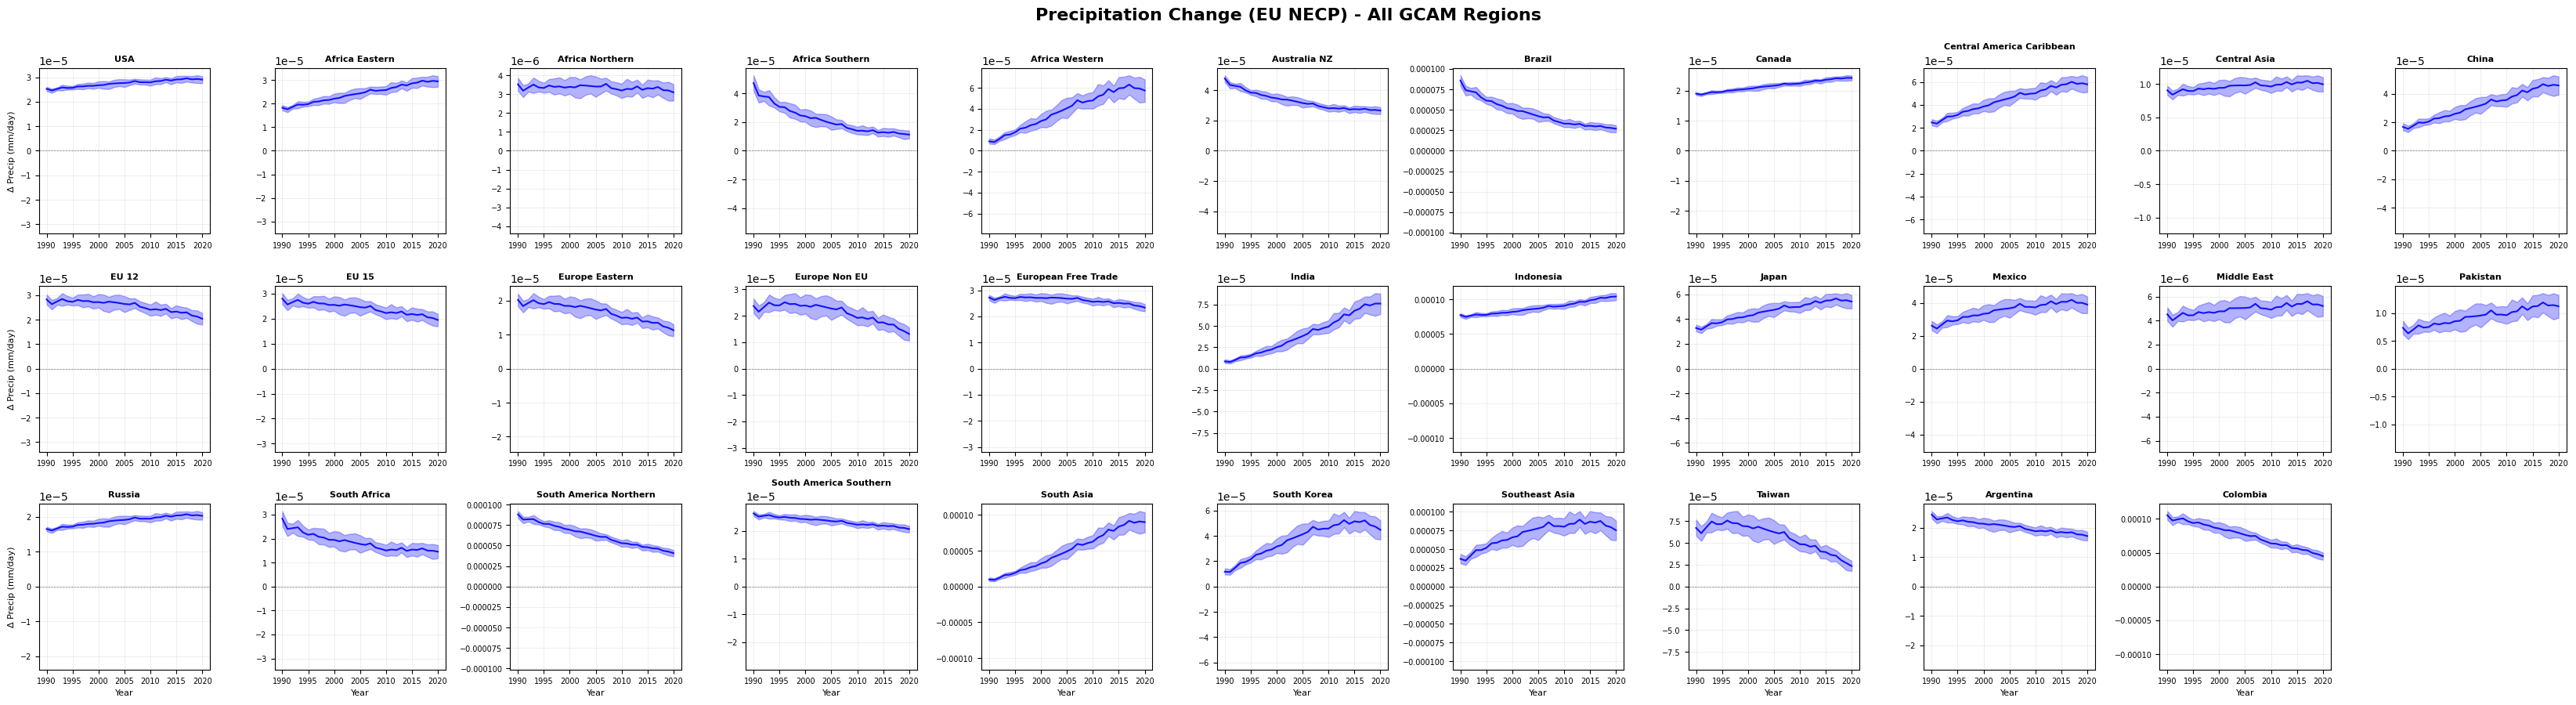

In [18]:
# Plot Precipitation for all GCAM regions (3x11 grid)
fig, axes = plt.subplots(3, 11, figsize=(33, 9))
fig.suptitle('Precipitation Change (EU NECP) - All GCAM Regions', 
             fontsize=16, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

for idx, region_name in enumerate(region_names):
    ax = axes_flat[idx]
    
    # Get precipitation data for this region
    key = f'regional:custom:{region_name}'
    pr_data = ensemble['pr'].timeseries[key]
    
    # Convert to annual means
    pr_annual = np.array([resample_annual(real) for real in pr_data])
    
    # Calculate statistics
    mean = pr_annual.mean(axis=0)
    p5 = np.percentile(pr_annual, 5, axis=0)
    p95 = np.percentile(pr_annual, 95, axis=0)
    
    # Plot
    ax.plot(years, mean, 'b-', linewidth=1.5, alpha=0.9)
    ax.fill_between(years, p5, p95, alpha=0.3, color='blue')
    
    # Add zero line for reference
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Formatting
    ax.set_title(region_name.replace('_', ' '), fontsize=8, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=7)
    
    # Only show y-label on leftmost plots
    if idx % 11 == 0:
        ax.set_ylabel('Δ Precip (mm/day)', fontsize=8)
    
    # Only show x-label on bottom row
    if idx >= 22:
        ax.set_xlabel('Year', fontsize=8)
    
    # Set y-limits (will vary by region, but centered on 0)
    y_max = max(abs(p5.min()), abs(p95.max())) * 1.1
    ax.set_ylim(-y_max, y_max)

# Hide unused subplots
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:

# Cell 1: Define major cities for each GCAM region
gcam_cities = {
    'USA': {'city': 'New York', 'lat': 40.7, 'lon': -74.0},
    'Africa_Eastern': {'city': 'Nairobi', 'lat': -1.3, 'lon': 36.8},
    'Africa_Northern': {'city': 'Cairo', 'lat': 30.0, 'lon': 31.2},
    'Africa_Southern': {'city': 'Johannesburg', 'lat': -26.2, 'lon': 28.0},
    'Africa_Western': {'city': 'Lagos', 'lat': 6.5, 'lon': 3.4},
    'Australia_NZ': {'city': 'Sydney', 'lat': -33.9, 'lon': 151.2},
    'Brazil': {'city': 'São Paulo', 'lat': -23.5, 'lon': -46.6},
    'Canada': {'city': 'Toronto', 'lat': 43.7, 'lon': -79.4},
    'Central_America_Caribbean': {'city': 'Mexico City', 'lat': 19.4, 'lon': -99.1},
    'Central_Asia': {'city': 'Almaty', 'lat': 43.2, 'lon': 76.9},
    'China': {'city': 'Shanghai', 'lat': 31.2, 'lon': 121.5},
    'EU_12': {'city': 'Warsaw', 'lat': 52.2, 'lon': 21.0},
    'EU_15': {'city': 'Paris', 'lat': 48.9, 'lon': 2.4},
    'Europe_Eastern': {'city': 'Kiev', 'lat': 50.5, 'lon': 30.5},
    'Europe_Non_EU': {'city': 'Belgrade', 'lat': 44.8, 'lon': 20.5},
    'European_Free_Trade': {'city': 'Oslo', 'lat': 59.9, 'lon': 10.8},
    'India': {'city': 'Mumbai', 'lat': 19.1, 'lon': 72.9},
    'Indonesia': {'city': 'Jakarta', 'lat': -6.2, 'lon': 106.8},
    'Japan': {'city': 'Tokyo', 'lat': 35.7, 'lon': 139.7},
    'Mexico': {'city': 'Guadalajara', 'lat': 20.7, 'lon': -103.3},
    'Middle_East': {'city': 'Riyadh', 'lat': 24.7, 'lon': 46.7},
    'Pakistan': {'city': 'Karachi', 'lat': 24.9, 'lon': 67.0},
    'Russia': {'city': 'Moscow', 'lat': 55.8, 'lon': 37.6},
    'South_Africa': {'city': 'Cape Town', 'lat': -33.9, 'lon': 18.4},
    'South_America_Northern': {'city': 'Bogotá', 'lat': 4.7, 'lon': -74.1},
    'South_America_Southern': {'city': 'Buenos Aires', 'lat': -34.6, 'lon': -58.4},
    'South_Asia': {'city': 'Dhaka', 'lat': 23.8, 'lon': 90.4},
    'South_Korea': {'city': 'Seoul', 'lat': 37.6, 'lon': 127.0},
    'Southeast_Asia': {'city': 'Bangkok', 'lat': 13.8, 'lon': 100.5},
    'Taiwan': {'city': 'Taipei', 'lat': 25.0, 'lon': 121.6},
    'Argentina': {'city': 'Córdoba', 'lat': -31.4, 'lon': -64.2},
    'Colombia': {'city': 'Medellín', 'lat': 6.2, 'lon': -75.6}
}

print(f"Defined {len(gcam_cities)} major cities for GCAM regions")
for region, city_info in gcam_cities.items():
    print(f"  {region:30s} → {city_info['city']:20s} ({city_info['lat']:6.1f}°, {city_info['lon']:7.1f}°)")




Defined 32 major cities for GCAM regions
  USA                            → New York             (  40.7°,   -74.0°)
  Africa_Eastern                 → Nairobi              (  -1.3°,    36.8°)
  Africa_Northern                → Cairo                (  30.0°,    31.2°)
  Africa_Southern                → Johannesburg         ( -26.2°,    28.0°)
  Africa_Western                 → Lagos                (   6.5°,     3.4°)
  Australia_NZ                   → Sydney               ( -33.9°,   151.2°)
  Brazil                         → São Paulo            ( -23.5°,   -46.6°)
  Canada                         → Toronto              (  43.7°,   -79.4°)
  Central_America_Caribbean      → Mexico City          (  19.4°,   -99.1°)
  Central_Asia                   → Almaty               (  43.2°,    76.9°)
  China                          → Shanghai             (  31.2°,   121.5°)
  EU_12                          → Warsaw               (  52.2°,    21.0°)
  EU_15                          → Paris       

In [20]:

# Cell 2: Generate ensemble with city point locations
# Build timeseries list with city points
timeseries = ['global']
timeseries += [f"point:{gcam_cities[region]['lat']},{gcam_cities[region]['lon']}"
               for region in gcam_cities.keys()]

print(f"\nGenerating timeseries for {len(timeseries)} locations:")
print(f"  - 1 global mean")
print(f"  - {len(gcam_cities)} city point locations")

# Generate ensemble with degree days for city points
ensemble_cities = emulator.generate_ensemble_outputs(
    scenario={
        'emissions': 'notebook_data/eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt',
        'name': 'EU_NECP_2024'
    },
    start_year=2020,
    end_year=2050,
    n_realizations=10,
    timeseries=timeseries,
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

print(f"\n✅ Ensemble generated for {len(gcam_cities)} cities!")




Generating timeseries for 33 locations:
  - 1 global mean
  - 32 city point locations
Generating ensemble for EU_NECP_2024
  Years: 2020-2050
  Realizations: 10

📊 Generating TAS...
   → Time series: 33 aggregations
      → Computing pattern scaling for tas, custom scenario 'EU_NECP_2024'...
      → Loaded emissions from eu_necp_ltt_em_gases_vupdate_2024_WMO_added_new_em_DiamondGCM-Europe.txt
      → Loaded concentrations from ssp245_conc_RCMIP.txt
      → Emissions data ends at 2050, extending to 2100 (holding final values)
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 10 stochastic PC realizations...
      • global
      • point:40.7,-74.0
[-90.         -89.05759162 -88.11518325 -87.17277487 -86.23036649
 -85.28795812 -84.34554974 -83.40314136 -82.46073298 -81.51832461
 -80.57591623 -79.63350785 -78.69109948 -77.7486911  -76.80628272
 -75.86387435 -74.9

In [21]:

# Cell 3: Extract and organize degree days by region
# Create a mapping from point location to region name
point_to_region = {}
for region, city_info in gcam_cities.items():
    point_key = f"point:{city_info['lat']},{city_info['lon']}"
    point_to_region[point_key] = region

# Extract HDD and CDD for each region's city
region_hdd = {}
region_cdd = {}

for point_key, region in point_to_region.items():
    region_hdd[region] = ensemble_cities['tas'].impacts['hdd'][point_key]
    region_cdd[region] = ensemble_cities['tas'].impacts['cdd'][point_key]

print("Degree days extracted for regions:")
print(f"\nSample - HDD and CDD for first 5 regions:")
for i, region in enumerate(list(gcam_cities.keys())[:5]):
    hdd_mean = region_hdd[region].mean()
    cdd_mean = region_cdd[region].mean()
    print(f"  {region:30s} (via {gcam_cities[region]['city']:15s}): "
          f"HDD={hdd_mean:7.1f}, CDD={cdd_mean:7.1f}")


Degree days extracted for regions:

Sample - HDD and CDD for first 5 regions:
  USA                            (via New York       ): HDD= 2489.5, CDD=  680.1
  Africa_Eastern                 (via Nairobi        ): HDD=    5.9, CDD=  824.2
  Africa_Northern                (via Cairo          ): HDD=  535.1, CDD= 1738.7
  Africa_Southern                (via Johannesburg   ): HDD=  724.2, CDD=  612.9
  Africa_Western                 (via Lagos          ): HDD=    0.0, CDD= 3269.5


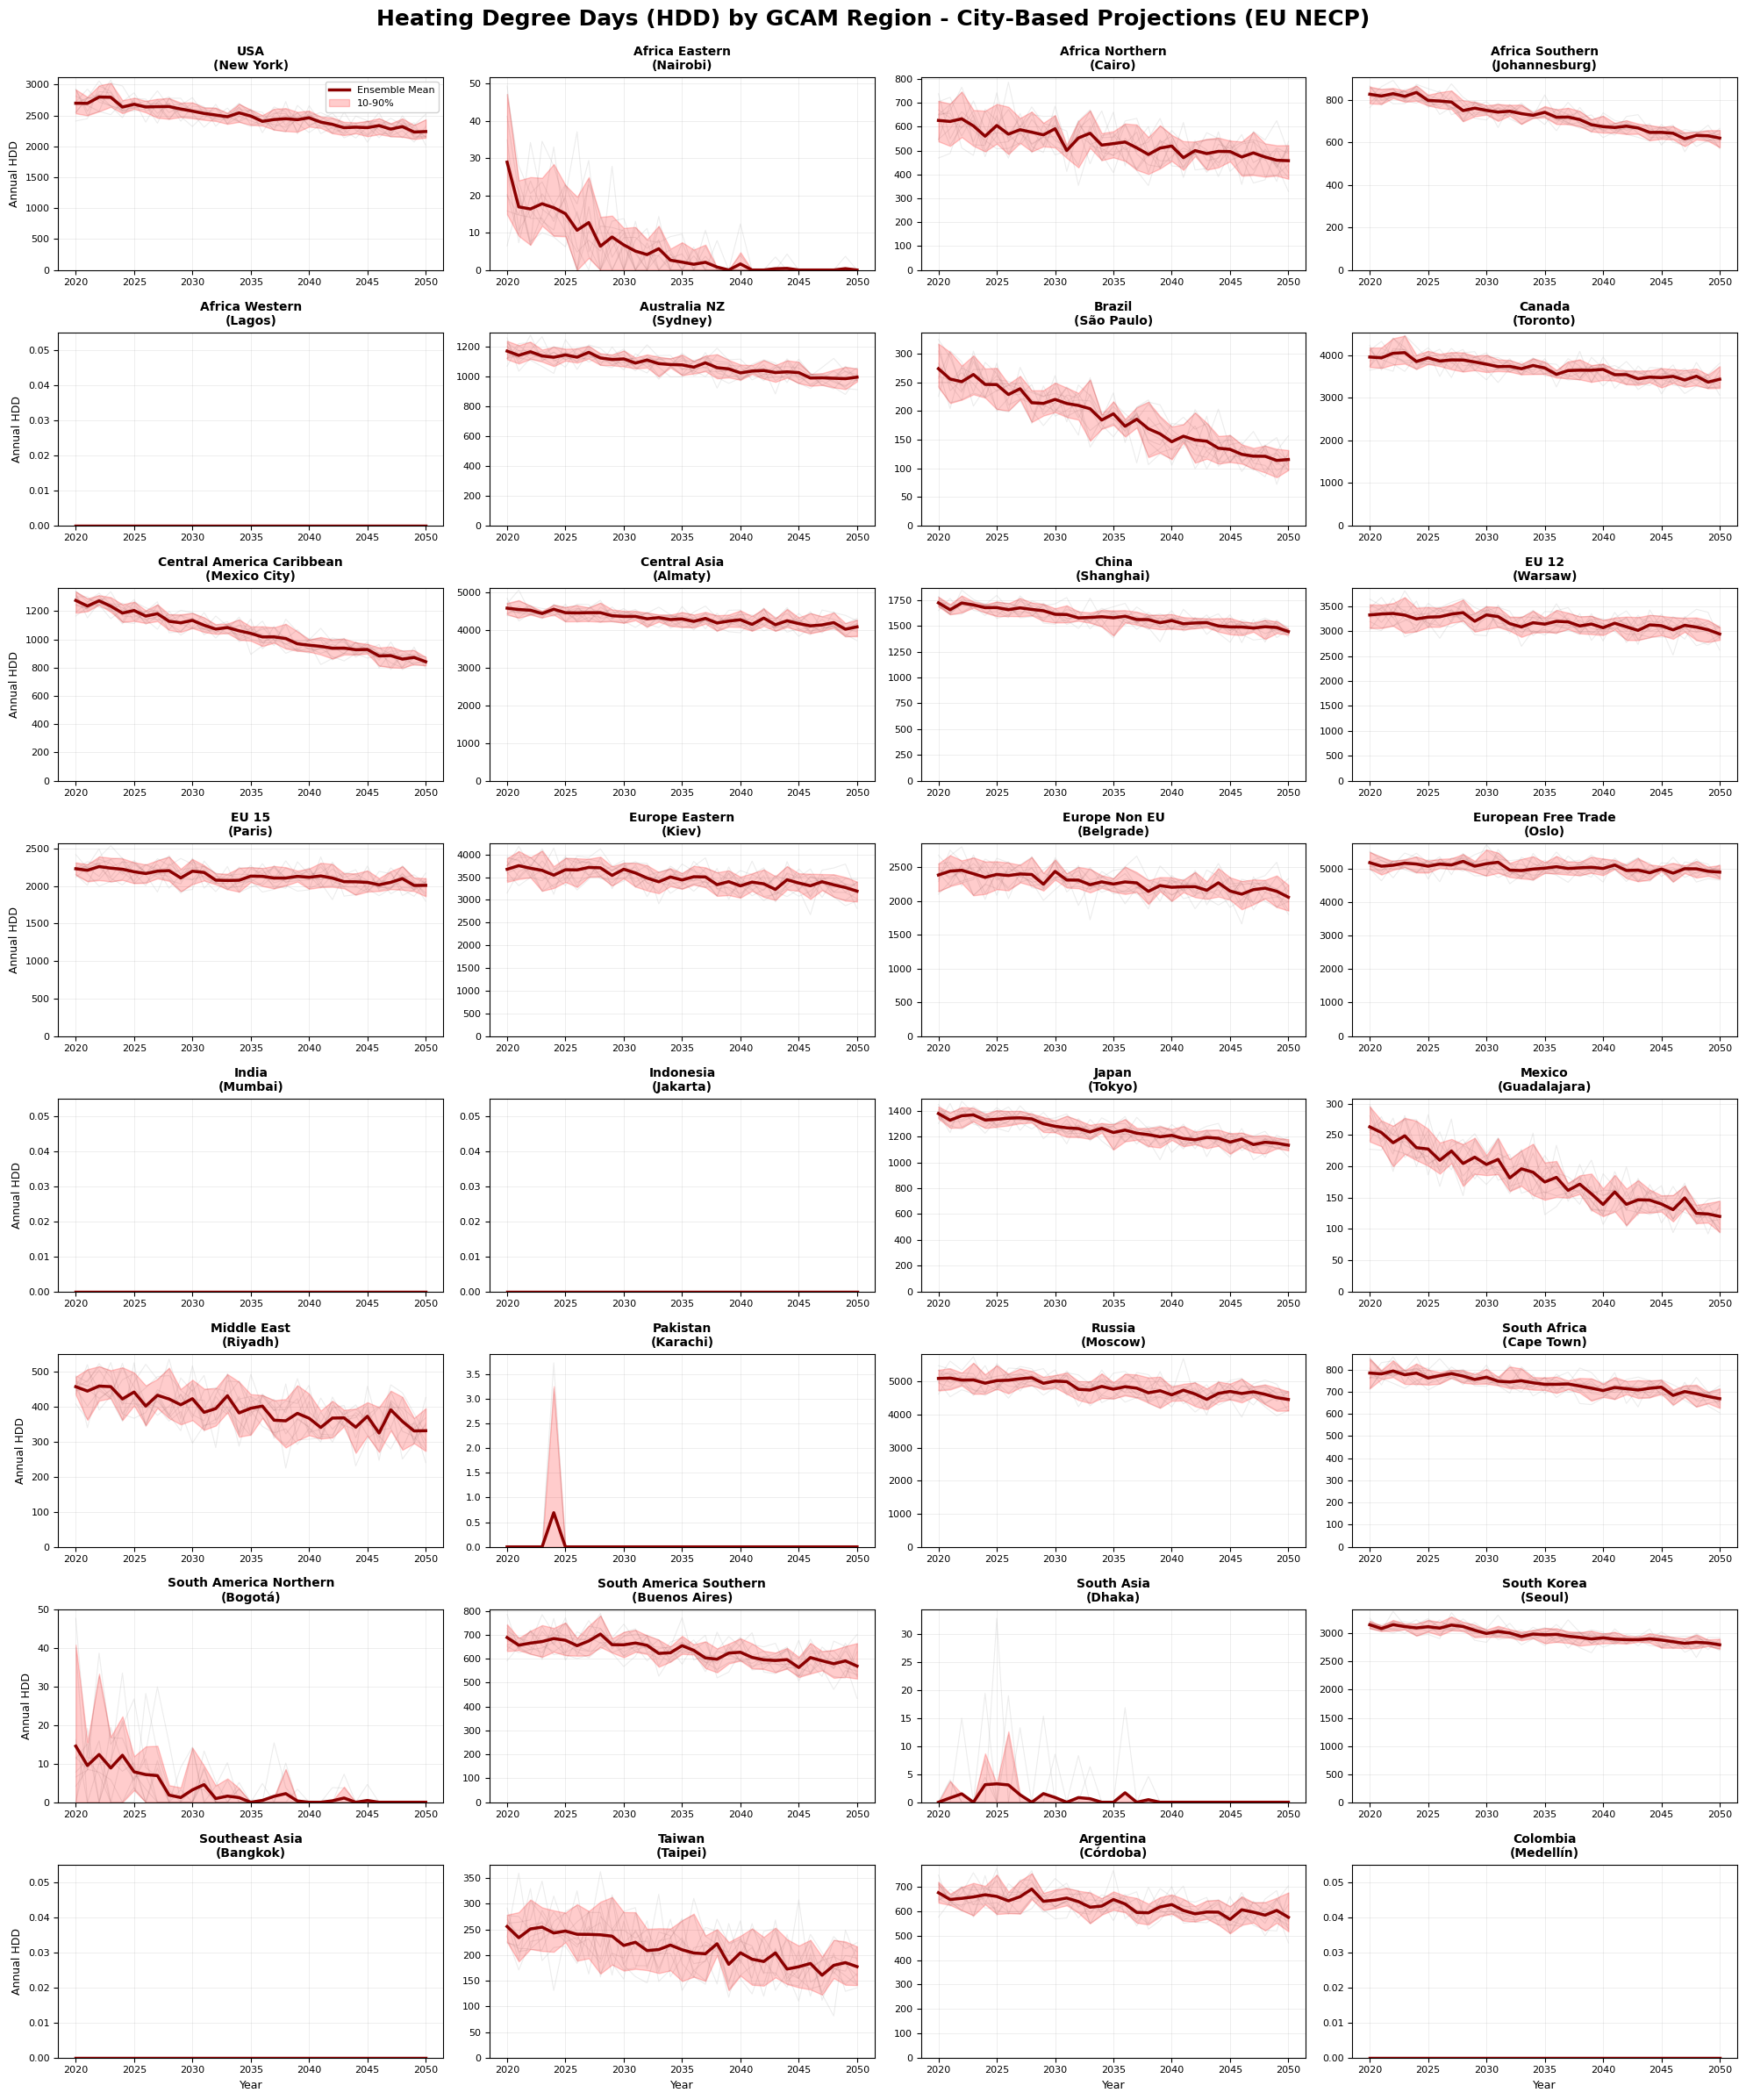

In [22]:
# Plot HDD for all GCAM cities - individual subplots
fig, axes = plt.subplots(8, 4, figsize=(20, 24))
fig.suptitle('Heating Degree Days (HDD) by GCAM Region - City-Based Projections (EU NECP)',
             fontsize=18, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

regions_ordered = list(gcam_cities.keys())
n_regions = len(regions_ordered)

for idx, region in enumerate(regions_ordered):
    ax = axes_flat[idx]

    # Get HDD data for this region's city
    hdd_data = region_hdd[region]  # Shape: (n_realizations, n_years)
    n_realizations, n_years_data = hdd_data.shape
    years = np.arange(2020, 2020 + n_years_data)

    # Plot individual ensemble members in background (light gray)
    for realization in range(n_realizations):
        ax.plot(years, hdd_data[realization, :],
                color='gray', alpha=0.15, linewidth=0.8, zorder=1)

    # Plot ensemble mean in foreground (bold red)
    mean = hdd_data.mean(axis=0)
    ax.plot(years, mean, color='darkred', linewidth=2.5,
            label='Ensemble Mean', zorder=3)

    # Add percentile envelope for reference
    p10 = np.percentile(hdd_data, 10, axis=0)
    p90 = np.percentile(hdd_data, 90, axis=0)
    ax.fill_between(years, p10, p90, alpha=0.2, color='red',
                     label='10-90%', zorder=2)

    # Formatting
    city_name = gcam_cities[region]['city']
    ax.set_title(f"{region.replace('_', ' ')}\n({city_name})",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=8)

    # Only show y-label on leftmost plots
    if idx % 4 == 0:
        ax.set_ylabel('Annual HDD', fontsize=9)

    # Only show x-label on bottom row
    if idx >= 28:
        ax.set_xlabel('Year', fontsize=9)

    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # Set reasonable y-limits (HDD ranges from ~0 for tropics to ~6000+ for cold regions)
    ax.set_ylim(bottom=0)

# Hide unused subplots
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()


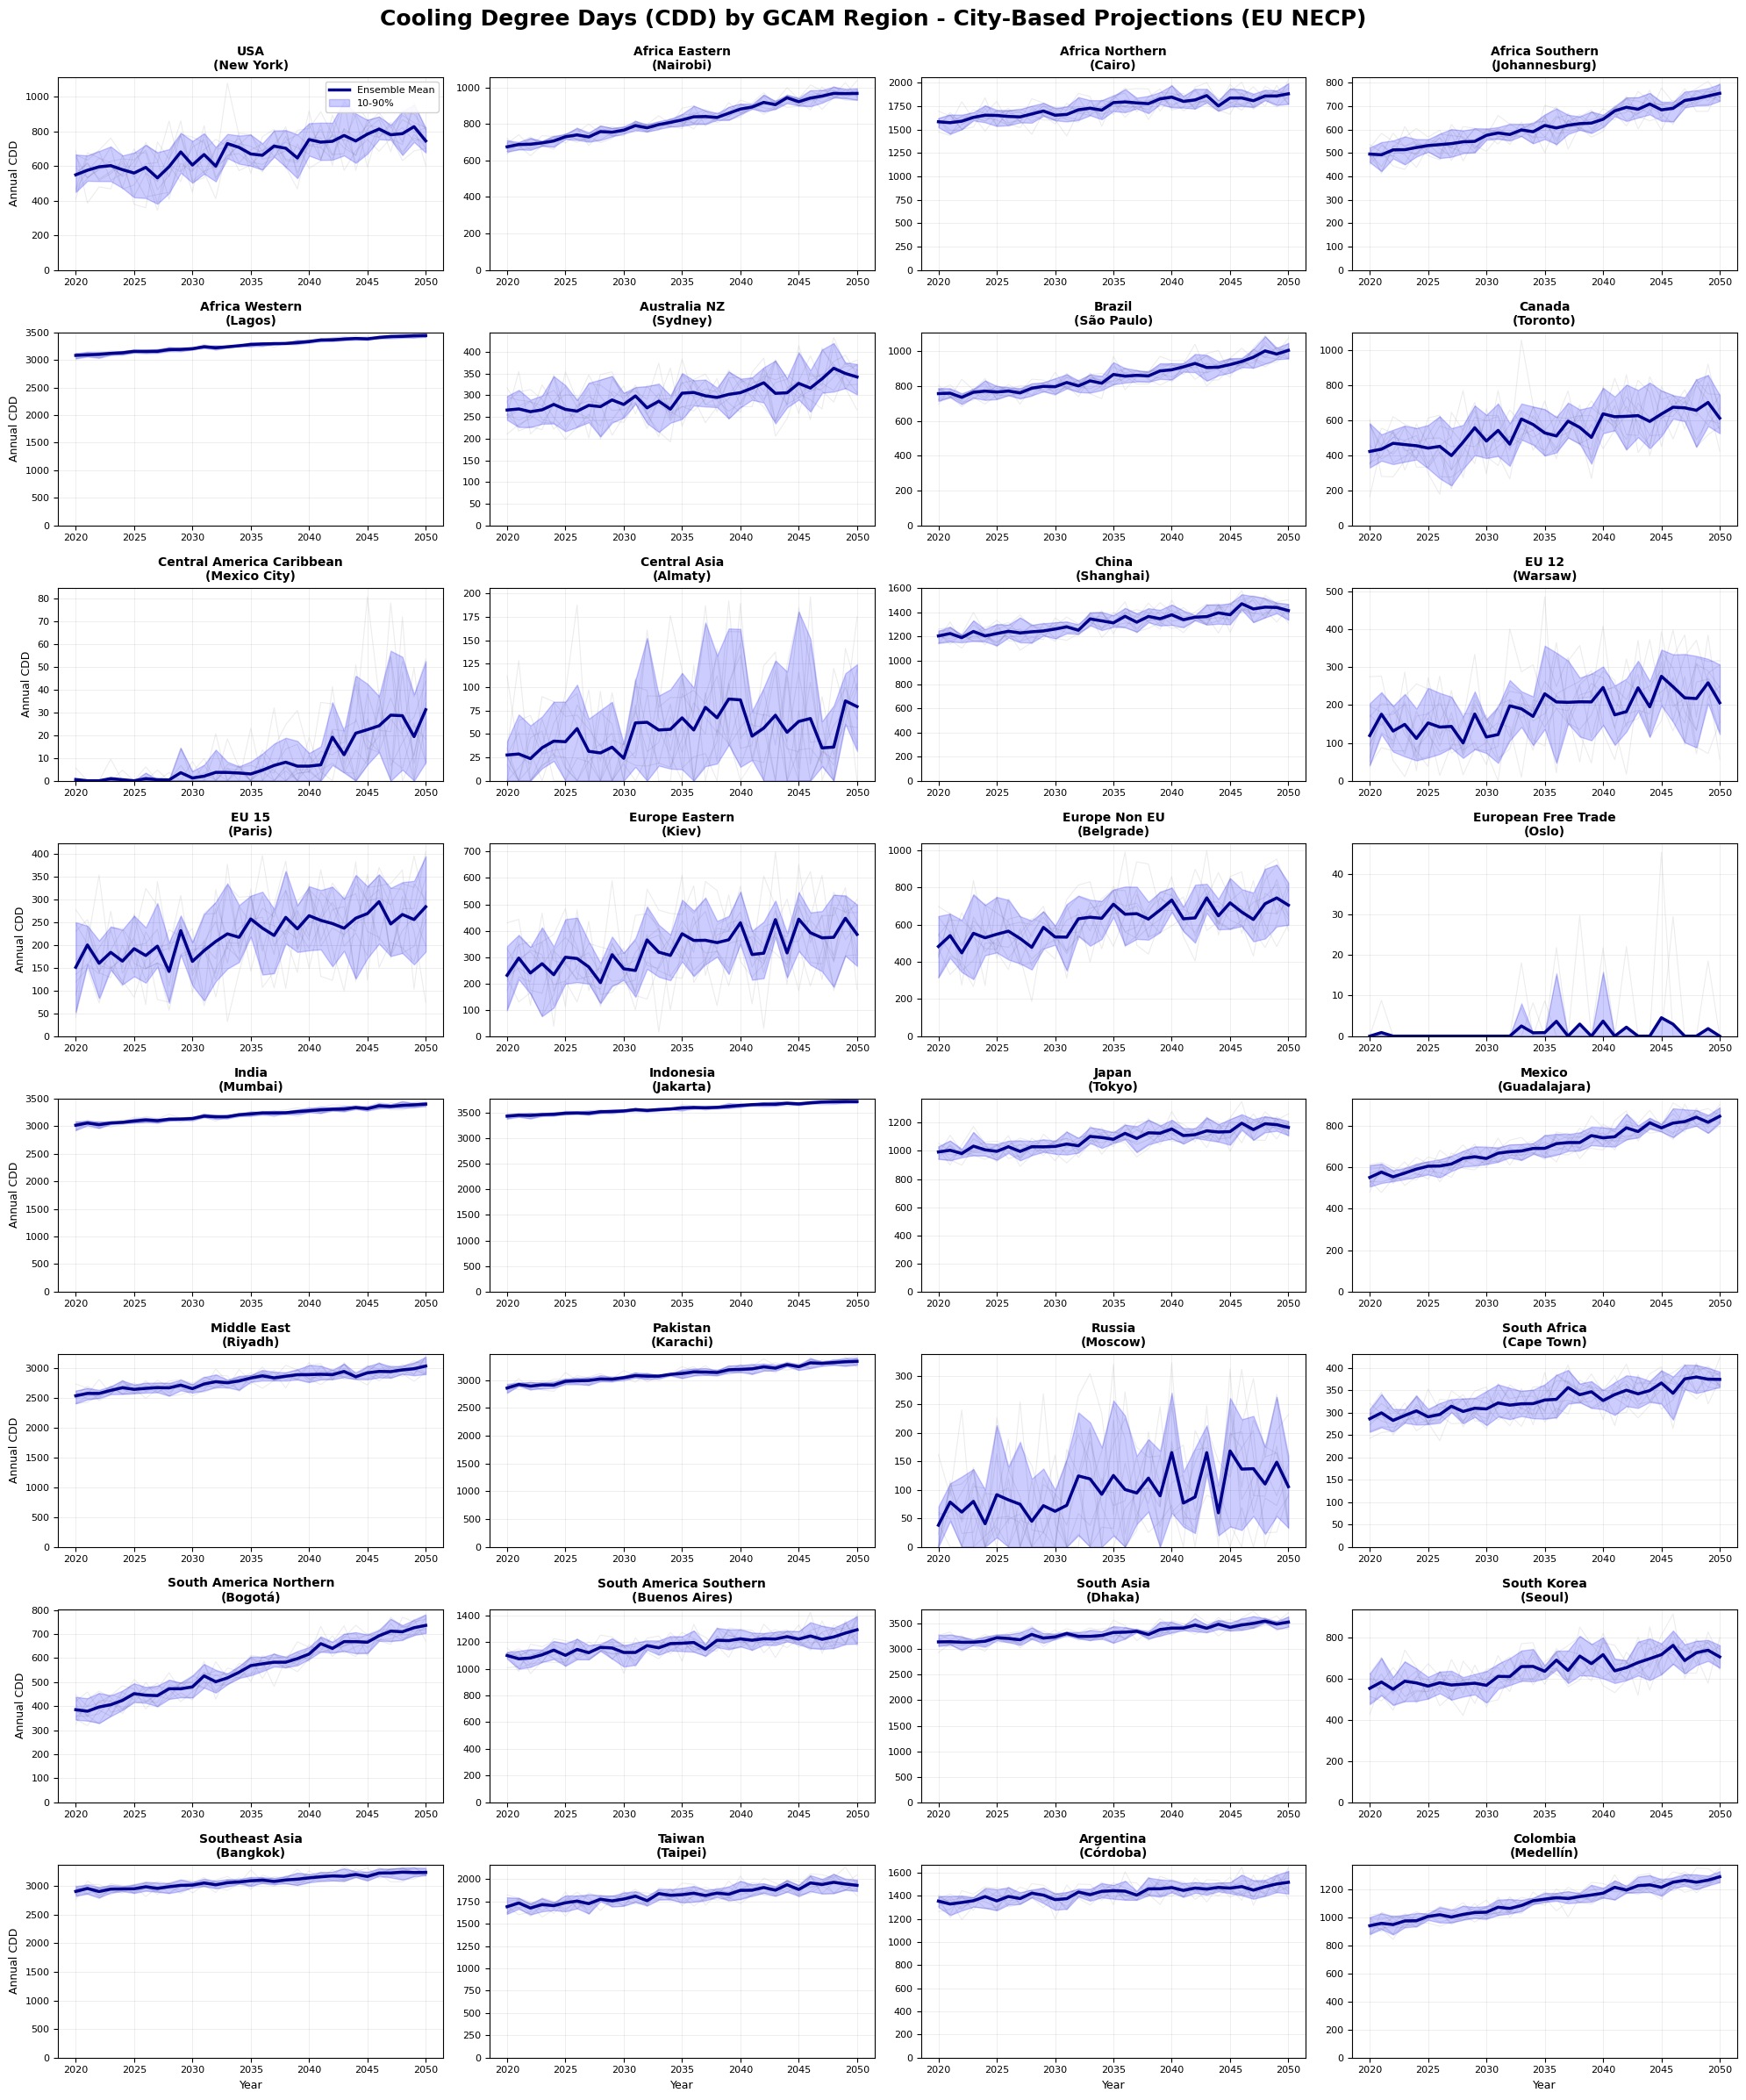

In [25]:
# Plot HDD for all GCAM cities - individual subplots
fig, axes = plt.subplots(8, 4, figsize=(20, 24))
fig.suptitle('Cooling Degree Days (CDD) by GCAM Region - City-Based Projections (EU NECP)',
             fontsize=18, fontweight='bold', y=0.995)

axes_flat = axes.flatten()

regions_ordered = list(gcam_cities.keys())
n_regions = len(regions_ordered)

for idx, region in enumerate(regions_ordered):
    ax = axes_flat[idx]

    # Get HDD data for this region's city
    cdd_data = region_cdd[region]  # Shape: (n_realizations, n_years)
    n_realizations, n_years_data = cdd_data.shape
    years = np.arange(2020, 2020 + n_years_data)

    # Plot individual ensemble members in background (light gray)
    for realization in range(n_realizations):
        ax.plot(years, cdd_data[realization, :],
                color='gray', alpha=0.15, linewidth=0.8, zorder=1)

    # Plot ensemble mean in foreground (bold red)
    mean = cdd_data.mean(axis=0)
    ax.plot(years, mean, color='darkblue', linewidth=2.5,
            label='Ensemble Mean', zorder=3)

    # Add percentile envelope for reference
    p10 = np.percentile(cdd_data, 10, axis=0)
    p90 = np.percentile(cdd_data, 90, axis=0)
    ax.fill_between(years, p10, p90, alpha=0.2, color='blue',
                     label='10-90%', zorder=2)

    # Formatting
    city_name = gcam_cities[region]['city']
    ax.set_title(f"{region.replace('_', ' ')}\n({city_name})",
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=8)

    # Only show y-label on leftmost plots
    if idx % 4 == 0:
        ax.set_ylabel('Annual CDD', fontsize=9)

    # Only show x-label on bottom row
    if idx >= 28:
        ax.set_xlabel('Year', fontsize=9)

    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # Set reasonable y-limits (HDD ranges from ~0 for tropics to ~6000+ for cold regions)
    ax.set_ylim(bottom=0)

# Hide unused subplots
for idx in range(n_regions, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

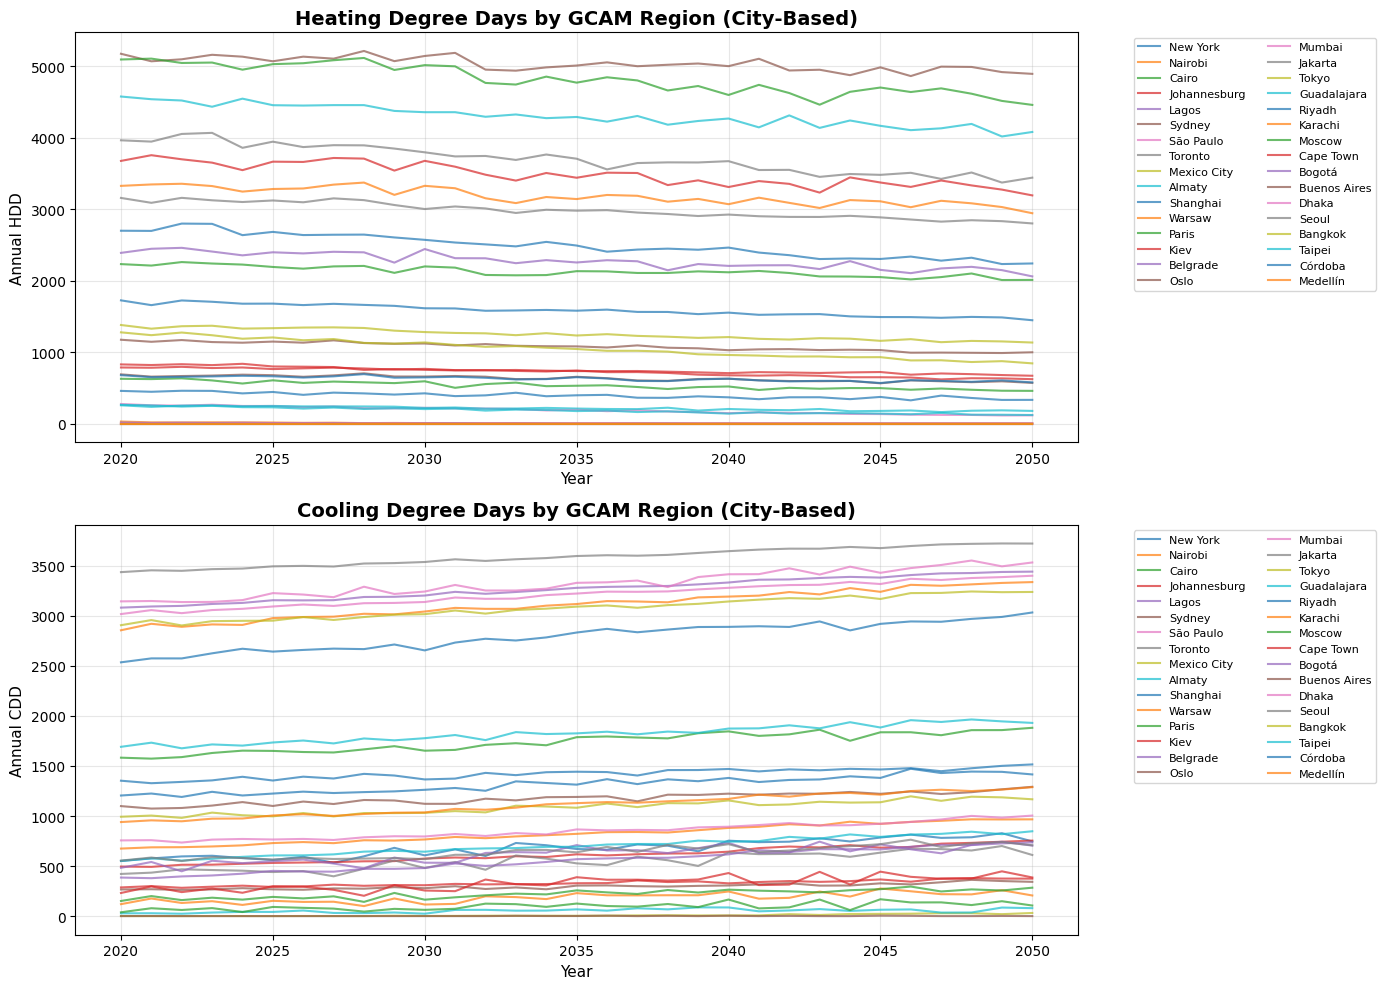


Degree Days Summary (2020s vs 2040s):
Region                         City             HDD 2020s  HDD 2040s  CDD 2020s  CDD 2040s
USA                            New York              2682       2328        587        776
Africa_Eastern                 Nairobi                 15          0        716        929
Africa_Northern                Cairo                  595        487       1632       1827
Africa_Southern                Johannesburg           803        652        524        699
Africa_Western                 Lagos                    0          0       3137       3391
Australia_NZ                   Sydney                1144       1016        271        326
Brazil                         São Paulo              243        135        767        936
Canada                         Toronto               3932       3499        455        642
Central_America_Caribbean      Mexico City           1201        915          1         19
Central_Asia                   Almaty              

In [26]:


# Cell 4: Plot HDD and CDD for all GCAM cities
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Prepare data for plotting
regions_ordered = list(gcam_cities.keys())
n_regions = len(regions_ordered)
n_years = region_hdd[regions_ordered[0]].shape[1]  # (n_realizations, n_years)
years = np.arange(2020, 2020 + n_years)

# Plot HDD
ax1.set_title('Heating Degree Days by GCAM Region (City-Based)',
              fontsize=14, fontweight='bold')
for region in regions_ordered:
    hdd_data = region_hdd[region]
    mean = hdd_data.mean(axis=0)
    ax1.plot(years, mean, linewidth=1.5, alpha=0.7, label=gcam_cities[region]['city'])

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Annual HDD', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)

# Plot CDD
ax2.set_title('Cooling Degree Days by GCAM Region (City-Based)',
              fontsize=14, fontweight='bold')
for region in regions_ordered:
    cdd_data = region_cdd[region]
    mean = cdd_data.mean(axis=0)
    ax2.plot(years, mean, linewidth=1.5, alpha=0.7, label=gcam_cities[region]['city'])

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Annual CDD', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


# Cell 5: Summary statistics table
# Calculate 2020s vs 2040s comparison
decade_2020s = slice(0, 10)  # 2020-2029
decade_2040s = slice(20, 30)  # 2040-2049

print("\nDegree Days Summary (2020s vs 2040s):")
print("="*90)
print(f"{'Region':<30} {'City':<15} {'HDD 2020s':>10} {'HDD 2040s':>10} {'CDD 2020s':>10} {'CDD 2040s':>10}")
print("="*90)

for region in regions_ordered:
    city = gcam_cities[region]['city']

    hdd_2020s = region_hdd[region][:, decade_2020s].mean()
    hdd_2040s = region_hdd[region][:, decade_2040s].mean()
    cdd_2020s = region_cdd[region][:, decade_2020s].mean()
    cdd_2040s = region_cdd[region][:, decade_2040s].mean()

    print(f"{region:<30} {city:<15} {hdd_2020s:10.0f} {hdd_2040s:10.0f} "
          f"{cdd_2020s:10.0f} {cdd_2040s:10.0f}")

## Export Degree Days Data to CSV

Export HDD and CDD timeseries for all GCAM regions in an easily interpretable format for scenario developers.

In [53]:
import pandas as pd
import os

# Create output directory for CSV files
csv_output_dir = 'output_data'
os.makedirs(csv_output_dir, exist_ok=True)

# Get years array
n_years = region_hdd[list(gcam_cities.keys())[0]].shape[1]
years = list(range(2020, 2020 + n_years))

# ========== Export HDD Data ==========
# Create DataFrame with ensemble mean for each region
hdd_mean_data = {'Year': years}
hdd_std_data = {'Year': years}
hdd_p10_data = {'Year': years}
hdd_p90_data = {'Year': years}

for region in gcam_cities.keys():
    city = gcam_cities[region]['city']
    hdd_data = region_hdd[region]  # (n_realizations, n_years)
    
    hdd_mean_data[f'{region} ({city})'] = hdd_data.mean(axis=0)
    hdd_std_data[f'{region} ({city})'] = hdd_data.std(axis=0)
    hdd_p10_data[f'{region} ({city})'] = np.percentile(hdd_data, 10, axis=0)
    hdd_p90_data[f'{region} ({city})'] = np.percentile(hdd_data, 90, axis=0)

# Save HDD files
hdd_mean_df = pd.DataFrame(hdd_mean_data)
hdd_mean_df.to_csv(f'{csv_output_dir}/HDD_ensemble_mean_by_region.csv', index=False)

hdd_std_df = pd.DataFrame(hdd_std_data)
hdd_std_df.to_csv(f'{csv_output_dir}/HDD_ensemble_std_by_region.csv', index=False)

hdd_uncertainty_df = pd.DataFrame(hdd_p10_data)
hdd_uncertainty_df.to_csv(f'{csv_output_dir}/HDD_p10_by_region.csv', index=False)

hdd_p90_df = pd.DataFrame(hdd_p90_data)
hdd_p90_df.to_csv(f'{csv_output_dir}/HDD_p90_by_region.csv', index=False)

# ========== Export CDD Data ==========
cdd_mean_data = {'Year': years}
cdd_std_data = {'Year': years}
cdd_p10_data = {'Year': years}
cdd_p90_data = {'Year': years}

for region in gcam_cities.keys():
    city = gcam_cities[region]['city']
    cdd_data = region_cdd[region]  # (n_realizations, n_years)
    
    cdd_mean_data[f'{region} ({city})'] = cdd_data.mean(axis=0)
    cdd_std_data[f'{region} ({city})'] = cdd_data.std(axis=0)
    cdd_p10_data[f'{region} ({city})'] = np.percentile(cdd_data, 10, axis=0)
    cdd_p90_data[f'{region} ({city})'] = np.percentile(cdd_data, 90, axis=0)

# Save CDD files
cdd_mean_df = pd.DataFrame(cdd_mean_data)
cdd_mean_df.to_csv(f'{csv_output_dir}/CDD_ensemble_mean_by_region.csv', index=False)

cdd_std_df = pd.DataFrame(cdd_std_data)
cdd_std_df.to_csv(f'{csv_output_dir}/CDD_ensemble_std_by_region.csv', index=False)

cdd_uncertainty_df = pd.DataFrame(cdd_p10_data)
cdd_uncertainty_df.to_csv(f'{csv_output_dir}/CDD_p10_by_region.csv', index=False)

cdd_p90_df = pd.DataFrame(cdd_p90_data)
cdd_p90_df.to_csv(f'{csv_output_dir}/CDD_p90_by_region.csv', index=False)

print(f"✅ CSV files exported to '{csv_output_dir}/'")
print(f"\nFiles created:")
print(f"  - HDD_ensemble_mean_by_region.csv")
print(f"  - HDD_ensemble_std_by_region.csv")
print(f"  - HDD_p10_by_region.csv (10th percentile)")
print(f"  - HDD_p90_by_region.csv (90th percentile)")
print(f"  - CDD_ensemble_mean_by_region.csv")
print(f"  - CDD_ensemble_std_by_region.csv")
print(f"  - CDD_p10_by_region.csv (10th percentile)")
print(f"  - CDD_p90_by_region.csv (90th percentile)")

# Display sample of the data
print(f"\n📊 Sample: HDD Ensemble Mean (first 5 years, first 5 regions)")
print(hdd_mean_df.iloc[:5, :6].to_string(index=False))

✅ CSV files exported to 'output_data/'

Files created:
  - HDD_ensemble_mean_by_region.csv
  - HDD_ensemble_std_by_region.csv
  - HDD_p10_by_region.csv (10th percentile)
  - HDD_p90_by_region.csv (90th percentile)
  - CDD_ensemble_mean_by_region.csv
  - CDD_ensemble_std_by_region.csv
  - CDD_p10_by_region.csv (10th percentile)
  - CDD_p90_by_region.csv (90th percentile)

📊 Sample: HDD Ensemble Mean (first 5 years, first 5 regions)
 Year  USA (New York)  Africa_Eastern (Nairobi)  Africa_Northern (Cairo)  Africa_Southern (Johannesburg)  Africa_Western (Lagos)
 2020     2696.901027                 28.960078               626.365356                      827.496015                     0.0
 2021     2694.532939                 16.942723               622.111895                      819.036130                     0.0
 2022     2796.863924                 16.385116               633.139232                      830.377297                     0.0
 2023     2793.220611                 17.782856  